In [1]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [2]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    detect_onsets,
    plot_waveform_with_onsets
)

In [3]:
%load_ext autoreload
%autoreload 2

### Query examples from Freesound

In [4]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [94]:
FREESOUND_API_KEY = os.getenv('FREESOUND_API_KEY')
FREESOUND_API_KEY = FREESOUND_API_KEY.strip('"')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [6]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [267]:
# Query for THIS RUN
query = 'dog bark'
filt = None
num_results = 20

In [268]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = query_freesound(
        query=query,
        filter=filt,
        client=client,
        fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
        num_results=num_results,
)


print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
subdir_path = AUDIO_DIR + query.replace(" ", "-")
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, subdir_path)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, subdir_path)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "query": query,
    "subdir_path": subdir_path
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

Retrieved 20 sound metadata objects
[1/20] Downloading sound ID 236282
[2/20] Downloading sound ID 625501
[3/20] Downloading sound ID 418108
[4/20] Downloading sound ID 749351
[5/20] Downloading sound ID 612858
[6/20] Downloading sound ID 160093
[7/20] Downloading sound ID 485962
[8/20] Downloading sound ID 649020
[9/20] Downloading sound ID 495658
[10/20] Downloading sound ID 242414
[11/20] Downloading sound ID 277058
[12/20] Downloading sound ID 536631
[13/20] Downloading sound ID 511606
[14/20] Downloading sound ID 553891
[15/20] Downloading sound ID 632330
[16/20] Downloading sound ID 623585
[17/20] Downloading sound ID 638003
[18/20] Downloading sound ID 699822
[19/20] Downloading sound ID 326207
[20/20] Downloading sound ID 347364
Saved metadata CSV: ../data/meta/dataset_2026-05-07_14-57-31.csv
Saved query log JSON: ../data/meta/dataset_2026-05-07_14-57-31.json


In [211]:
!ls ../data/meta

dataset_2026-05-06_20-07-03.csv   dataset_2026-05-07_14-31-08.csv
dataset_2026-05-06_20-07-03.json  dataset_2026-05-07_14-31-08.json


In [269]:
!ls ../data/audio

'"3-times"'  '"4-times"'   dog-bark


In [202]:
delete_dataset_with_gc(META_DIR + "dataset_2026-05-07_14-00-06.csv", META_DIR, AUDIO_DIR, dry_run=False)

Deleted metadata file: /workspace/data/meta/dataset_2026-05-07_14-00-06.csv
Deleted query file: /workspace/data/meta/dataset_2026-05-07_14-00-06.json
Deleted audio: /workspace/data/audio/4-times/722979_15435613-hq.ogg
Deleted audio: /workspace/data/audio/4-times/222438_2518-hq.ogg
Deleted audio: /workspace/data/audio/4-times/58874_111012-hq.ogg
Deleted audio: /workspace/data/audio/4-times/222406_2518-hq.ogg
Deleted audio: /workspace/data/audio/4-times/47310_107821-hq.ogg
Deleted audio: /workspace/data/audio/4-times/527742_11653850-hq.ogg
Deleted audio: /workspace/data/audio/4-times/36039_109798-hq.ogg
Deleted audio: /workspace/data/audio/4-times/38355_111012-hq.ogg
Deleted audio: /workspace/data/audio/4-times/222422_2518-hq.ogg
Deleted audio: /workspace/data/audio/4-times/511552_1676145-hq.ogg
Deleted audio: /workspace/data/audio/4-times/749858_16155788-hq.ogg
Deleted audio: /workspace/data/audio/4-times/708308_15362740-hq.ogg
Deleted audio: /workspace/data/audio/4-times/556471_1071316

### Show downloaded audio

In [103]:
!ls -lt ../data/audio/4-times

total 1284
-rw-r--r-- 1 root root  48090 May  7 14:00 556471_10713160-hq.ogg
-rw-r--r-- 1 root root  53640 May  7 14:00 527742_11653850-hq.ogg
-rw-r--r-- 1 root root  95804 May  7 14:00 515682_919187-hq.ogg
-rw-r--r-- 1 root root  66082 May  7 14:00 222390_2518-hq.ogg
-rw-r--r-- 1 root root  67693 May  7 14:00 222406_2518-hq.ogg
-rw-r--r-- 1 root root  69347 May  7 14:00 222422_2518-hq.ogg
-rw-r--r-- 1 root root  68009 May  7 14:00 222438_2518-hq.ogg
-rw-r--r-- 1 root root  49983 May  7 14:00 708308_15362740-hq.ogg
-rw-r--r-- 1 root root  18935 May  7 14:00 420951_8397738-hq.ogg
-rw-r--r-- 1 root root  79062 May  7 14:00 36039_109798-hq.ogg
-rw-r--r-- 1 root root 111635 May  7 14:00 37329_111012-hq.ogg
-rw-r--r-- 1 root root   2846 May  7 14:00 749858_16155788-hq.ogg
-rw-r--r-- 1 root root  56723 May  7 14:00 58874_111012-hq.ogg
-rw-r--r-- 1 root root  39137 May  7 14:00 47310_107821-hq.ogg
-rw-r--r-- 1 root root 159208 May  7 14:00 38355_111012-hq.ogg
-rw-r--r-- 1 root root 214838 May

In [13]:
# select a file manually
filename = "66113_877451-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/66113_877451-hq.ogg'

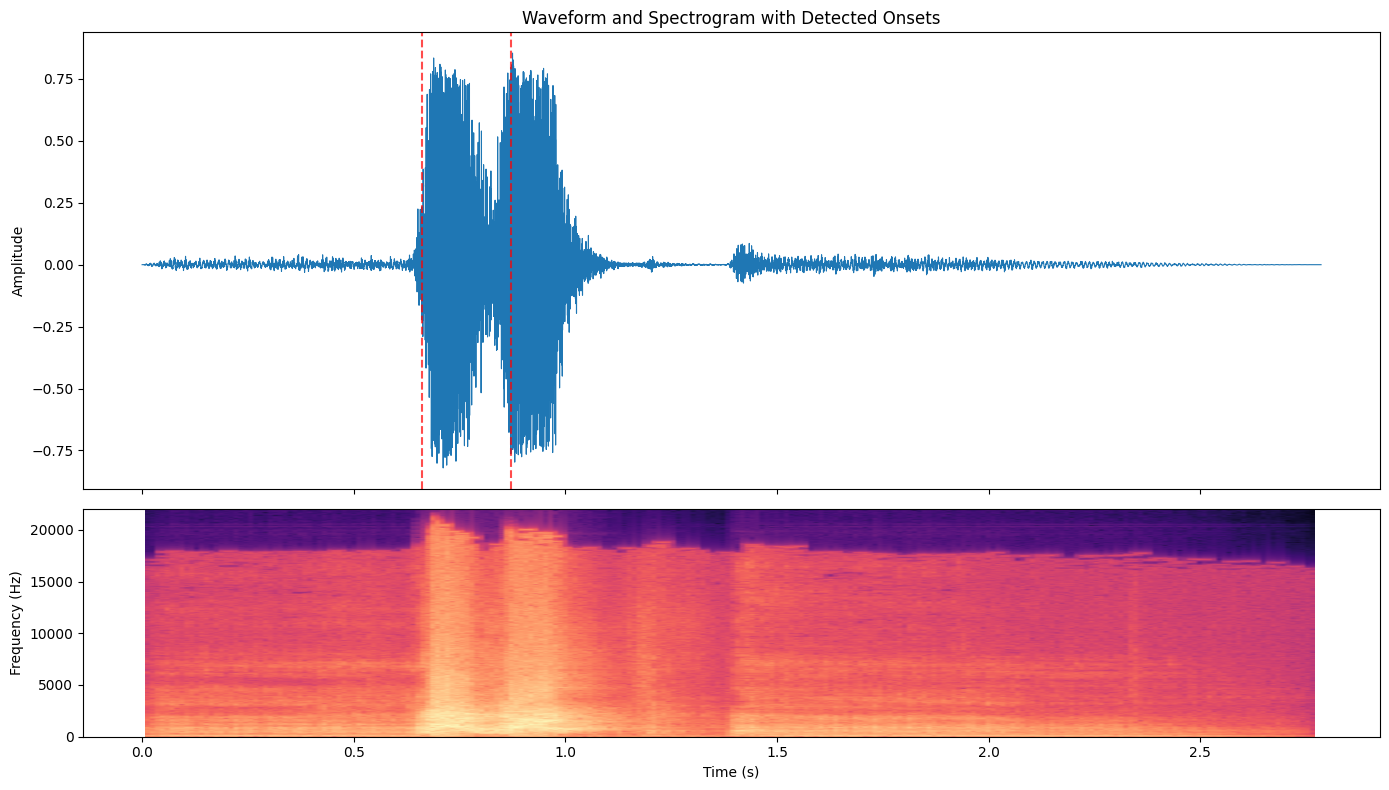

In [293]:
# select a file randomly
subdir = 'dog-bark'
filename = random.choice(os.listdir(AUDIO_DIR + subdir))
filepath = f"{AUDIO_DIR}/{subdir}/{filename}"
sound_id = int(filename[:filename.find("_")])

start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filepath)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)

--- Analyzing: 625501_13366994-hq.ogg ---
Total raw onsets detected: 2
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 625501 ---
File: 625501_13366994-hq.ogg
Method: hfc | Detected: 2 | In Pattern: 0


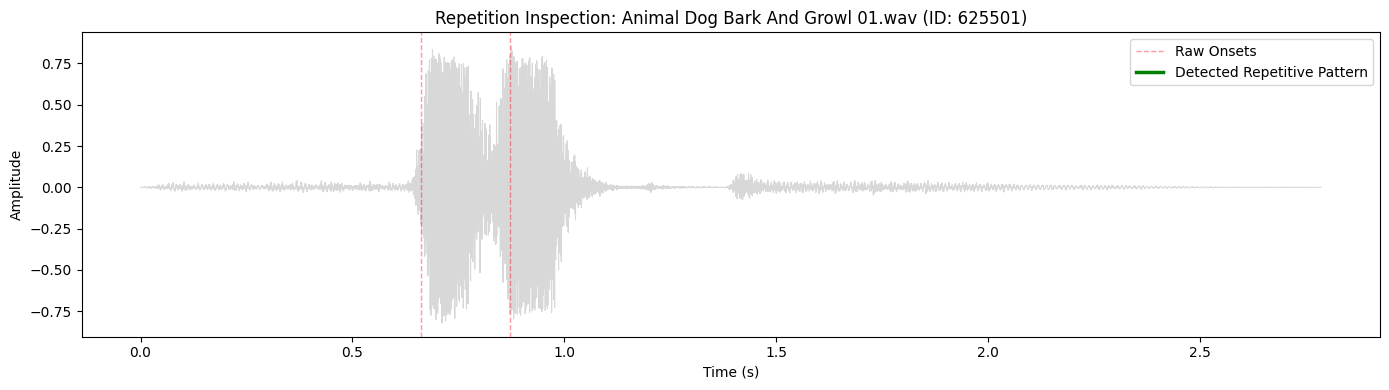

In [294]:
inspect_sound_with_repetition(META_DIR, sound_id)

---

### Analyze repetitiveness

In [33]:
import sklearn
import essentia.standard as es
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances

def analyze_repetitiveness(audio_path, sr=44100, window_ms=150, lat_threshold=0.08, eps=0.15):
    """
    Analyzes an audio file for repetitive percussive events.
    
    1. Detects onsets.
    2. Calculates LogAttackTime and MFCCs for the 150ms window after each onset.
    3. Filters out sounds with slow attacks (non-percussive).
    4. Clusters the remaining MFCC signatures to find repetitions.
    """
    print(f"--- Analyzing: {audio_path.split('/')[-1]} ---")
    
    # 1. load audio and detect onsets
    audio = es.MonoLoader(filename=audio_path, sampleRate=sr)()
    od_method = es.OnsetDetection(method='hfc')
    w = es.Windowing(type='hann')
    fft = es.FFT()
    c2p = es.CartesianToPolar()
    
    pool = essentia.Pool()
    for frame in es.FrameGenerator(audio, frameSize=1024, hopSize=512):
        mag, phase = c2p(fft(w(frame)))
        pool.add('odf.method', od_method(mag, phase))

    onsets = es.Onsets()(essentia.array([pool['odf.method']]), [1])
    print(f"Total raw onsets detected: {len(onsets)}")
    
    if len(onsets) == 0:
        return None
    
    # 2. extract Features per onset
    window_samples = int((window_ms / 1000.0) * sr)
    
    # Essentia extractors
    envelope = es.Envelope()
    log_attack = es.LogAttackTime()
    spectrum = es.Spectrum()
    mfcc = es.MFCC(inputSize=513)
    
    features = []
    last_onset_time = -1.0

    min_ioi = 0.25  # adjustable param
    
    for onset in onsets:
        # if this onset is too close the last valid one, skip it
        # (avoids picking up echoes of the sound events)
        if (onset - last_onset_time) < min_ioi:
            continue
        
        start_idx = int(onset * sr)
        end_idx = min(start_idx + window_samples, len(audio))
        segment = audio[start_idx:end_idx]
        
        # skip if too close to the end of the file
        if len(segment) < 1024:
            continue


        # Peak amplitude divided by RMS (average) amplitude
        peak_amp = np.max(np.abs(segment))
        rms_amp = np.sqrt(np.mean(segment**2)) + 1e-9 
        crest_factor = peak_amp / rms_amp

        # skip sounds that are not "peaky"
        if crest_factor < 5.0:  # adjustable parameter
            continue
            
        # LogAttackTime algorithm expects the envelope of the signal
        env = envelope(segment)
        try:
            # returns: (logAttackTime, attackStart, attackStop)
            lat = log_attack(env)[0] 
        except:
            lat = 1.0 # default high value if it fails
            
        # sound event similarity: MFCC;
        # - this method of measuring sound event similarity could be considered
        #   a variable parameter; this block would need to be rewritten in a more
        #   more modular fashion
        segment_mfccs = []
        for frame in es.FrameGenerator(segment, frameSize=1024, hopSize=512, startFromZero=True):
            _, mfcc_coeffs = mfcc(spectrum(w(frame)))
            
            # exclude the 0th coefficient (energy) so we cluster by timbre, not volume
            segment_mfccs.append(mfcc_coeffs[1:]) 
            
        mean_mfcc = np.mean(segment_mfccs, axis=0)

        last_onset_time = onset
        
        features.append({
            'time': onset,
            'lat': lat,
            'crest': crest_factor,
            'mfcc': mean_mfcc
        })

    if not features:
        print("No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).")
        return None
        
    df = pd.DataFrame(features)
    
    # 3. filter by Log Attack Time
    # - keep only sharp, fast attacks
    percussive_df = df[df['lat'] < lat_threshold].copy()
    print(f"Onsets passing LAT filter (< {lat_threshold}s): {len(percussive_df)}")
    
    if len(percussive_df) < 2:
        print("Not enough percussive events to cluster.\n")
        return None
        
    # 4. clustering (pairwise similarity)
    # - convert list of arrays to 2D numpy array
    X_mfcc = np.vstack(percussive_df['mfcc'].values)
    print("Percussive onset MFCCs shape", X_mfcc.shape)
    
    # compute cosine distance (great for spectral features)
    dist_matrix = pairwise_distances(X_mfcc, metric='cosine')

    print("Dist matrix shape:", dist_matrix.shape)
    
    # DBSCAN: groups events that are similar. eps is the distance threshold.
    clusterer = DBSCAN(eps=eps, min_samples=3, metric='precomputed')
    percussive_df['cluster'] = clusterer.fit_predict(dist_matrix)
    
    # count repetitions (excluding noise, which DBSCAN labels as -1)
    clusters = percussive_df[percussive_df['cluster'] != -1]
    
    if not clusters.empty:
        largest_cluster = clusters['cluster'].value_counts().idxmax()
        rep_count = len(clusters[clusters['cluster'] == largest_cluster])
        print(f"--> Found repeating event! Repetitions count: {rep_count}\n")
    else:
        print("--> No repeating clusters found.\n")
        
    return percussive_df

In [235]:
def inspect_sound_with_repetition(meta_dir, sound_id, method="hfc", window_ms=150):
    for csv_path in glob.glob(os.path.join(meta_dir, "dataset_*.csv")):
        df = pd.read_csv(csv_path)
        match = df[df["sound_id"] == sound_id]
        
        if not match.empty:
            row = match.iloc[0]
            local_path = row["local_path"]
            
            # 1. Get raw onsets for the background (Red lines)
            audio, onset_times = detect_onsets(local_path, method=method)
            
            # 2. Run your analysis function (Pass the PATH string)
            # This returns the DataFrame with 'time' and 'cluster' columns
            analysis_df = analyze_repetitiveness(local_path, window_ms=window_ms)
            
            # 3. Determine which onsets are "Repetitive"
            # We identify the largest cluster and get those timestamps
            rep_times = []
            if analysis_df is not None:
                valid_clusters = analysis_df[analysis_df['cluster'] != -1]
                if not valid_clusters.empty:
                    largest_cluster = valid_clusters['cluster'].value_counts().idxmax()
                    rep_times = valid_clusters[valid_clusters['cluster'] == largest_cluster]['time'].values

            print(f"--- Sound ID: {sound_id} ---")
            print(f"File: {os.path.basename(local_path)}")
            print(f"Method: {method} | Detected: {len(onset_times)} | In Pattern: {len(rep_times)}")

            # 4. Plotting
            sample_rate = 44100
            time_axis = np.arange(len(audio)) / sample_rate
            
            fig, ax = plt.subplots(figsize=(14, 4))
            ax.plot(time_axis, audio, color='gray', alpha=0.3, linewidth=0.8)
            
            # Draw all raw onsets as thin red lines first
            for t in onset_times:
                ax.axvline(t, color="red", linestyle="--", linewidth=1, alpha=0.4)
            
            # Draw repetitive onsets as thick green lines on top
            # We use np.isclose because float timestamps might have tiny rounding differences
            for rt in rep_times:
                ax.axvline(rt, color="green", linestyle="-", linewidth=2.5, alpha=0.9)
            
            ax.set_title(f"Repetition Inspection: {row['name']} (ID: {sound_id})")
            ax.set_ylabel("Amplitude")
            ax.set_xlabel("Time (s)")
            
            # Legend
            from matplotlib.lines import Line2D
            custom_lines = [Line2D([0], [0], color='red', lw=1, linestyle='--', alpha=0.4),
                            Line2D([0], [0], color='green', lw=2.5)]
            ax.legend(custom_lines, ['Raw Onsets', 'Detected Repetitive Pattern'])

            plt.tight_layout()
            plt.show()
            
            from IPython.display import Audio, display
            display(Audio(local_path))
            return

    print(f"Sound ID {sound_id} not found.")

--- Analyzing: 511552_1676145-hq.ogg ---
Total raw onsets detected: 1
No onsets survived the initial pre-filtering (IOI, segment length, or Crest Factor).
--- Sound ID: 511552 ---
File: 511552_1676145-hq.ogg
Method: hfc | Detected: 1 | In Pattern: 0


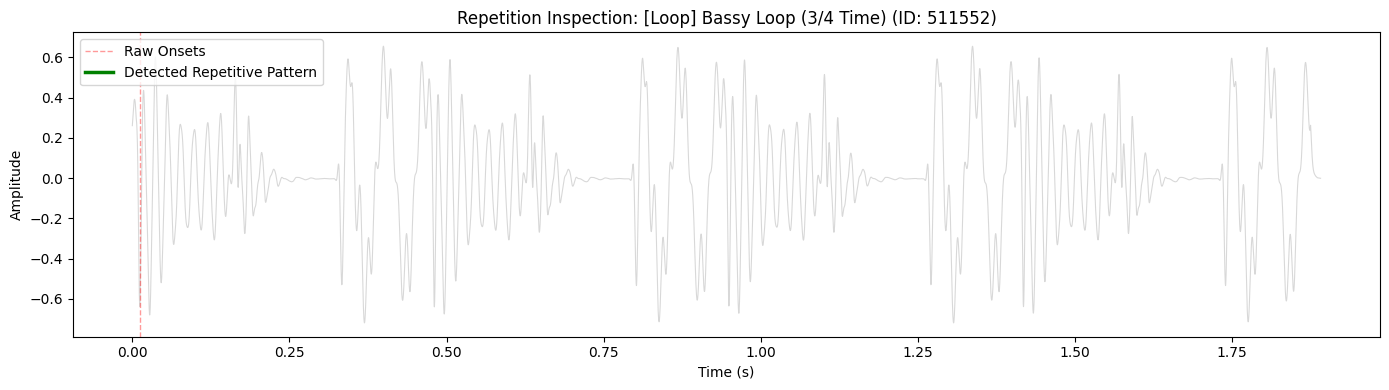

In [35]:
inspect_sound_with_repetition(META_DIR, 511552)

---

### GARBAGE

In [ ]:
import os
import glob
import json
import pandas as pd
from IPython.display import display, Audio

def _build_query_map(meta_dir):
    """Internal helper to map query strings to sets of unique Freesound IDs."""
    query_to_ids = {}
    global_unique_ids = set()
    
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        json_path = csv_path.rsplit(".", 1)[0] + ".json"
        
        # Fallback to filename
        query_str = os.path.basename(csv_path) 
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    data = json.load(f)
                    
                    if "queries" in data and isinstance(data["queries"], list):
                        # NORMALIZATION 1: Strip whitespace from every query
                        q_list = [q.get("query", "").strip() for q in data["queries"]]
                        query_str = " + ".join(filter(None, q_list)) 
            except Exception:
                pass
                
        df = pd.read_csv(csv_path)
        if "sound_id" in df.columns:
            # NORMALIZATION 2: Use lowercase keys for internal storage
            lookup_key = query_str.lower()
            
            if lookup_key not in query_to_ids:
                # We store the 'display_name' so the table still looks nice
                query_to_ids[lookup_key] = {"display_name": query_str, "ids": set()}
            
            unique_in_csv = df["sound_id"].unique()
            query_to_ids[lookup_key]["ids"].update(unique_in_csv)
            global_unique_ids.update(unique_in_csv)
            
    return query_to_ids, global_unique_ids

# ---------------------------------------------------------
def summarize_queries(meta_dir):
    query_map, global_unique = _build_query_map(meta_dir)
    
    print(f"{'Query String':<45} | {'Unique Sounds'}")
    print("-" * 65)
    
    # Sort by the display name
    for key in sorted(query_map.keys()):
        item = query_map[key]
        print(f"{item['display_name']:<45} | {len(item['ids'])}")
        
    print("-" * 65)
    print(f"{'TOTAL ABSOLUTE UNIQUE SOUNDS':<45} | {len(global_unique)}")

# ---------------------------------------------------------
# 2. Get IDs for a Specific Query
# ---------------------------------------------------------
def print_ids_for_query(meta_dir, target_query):
    """Given a query string, prints all associated Freesound IDs beautifully."""
    query_map, _ = _build_query_map(meta_dir)
    search_key = target_query.strip().lower()
    
    if search_key in query_map:
        item = query_map[search_key]
        
        # 1. Cast to int to remove the 'np.int64' branding
        # 2. Sort them so the list isn't jumping around randomly
        clean_ids = sorted([int(sid) for sid in item["ids"]])
        
        print(f"--- {item['display_name'].upper()} ({len(clean_ids)} sounds) ---")
        
        for sid in clean_ids:
            print(sid)
            
        return clean_ids
    else:
        print(f"Query '{target_query}' not found.")
        available = [v['display_name'] for v in query_map.values()]
        print(f"Available options: {available}")
        return []

# ---------------------------------------------------------
# 3. Inspect, Plot, and Play a Specific Sound ID
# ---------------------------------------------------------
def inspect_sound(meta_dir, sound_id):
    """
    Looks up a Freesound ID, prints metadata, plots the waveform/spectrogram 
    with onsets, and displays a playable audio widget.
    """
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        df = pd.read_csv(csv_path)
        
        if "sound_id" in df.columns:
            match = df[df["sound_id"] == sound_id]
            
            if not match.empty:
                row = match.iloc[0]
                local_path = row["local_path"]
                
                print(f"--- Sound ID: {sound_id} ---")
                print(f"Name: {row.get('name', 'N/A')}")
                print(f"Tags: {row.get('tags', 'N/A')}")
                print(f"Path: {local_path}\n")
                
                if not os.path.exists(local_path):
                    print("Error: Audio file not found on disk. Run ensure_datasets_audio().")
                    return
                
                # Run onset detection
                audio, onsets = detect_onsets(local_path)
                print(f"Detected {len(onsets)} onsets.")
                
                # Plot
                plot_waveform_with_onsets(audio, onsets)
                
                # Display playback widget
                display(Audio(local_path))
                return
                
    print(f"Sound ID {sound_id} not found in any metadata CSV.")